In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
#from matplotlib_venn import venn2, venn3
import seaborn as sns
from ALLCools.mcds import MCDS 

In [2]:
# mcds_path = './data/Arab10_All_mcds.mcds'
mcds_path = '../../hazel/gene_mcds/gene'
rna_path = '../../hazel/count_Arab13_with_TEs.csv'
meta_path ='../../hazel/merged_cluster_assignments.csv'

In [3]:
mcds = MCDS.open(mcds_paths = mcds_path, var_dim = 'gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path)
meta = meta.set_index('cell_id')

In [ ]:
meta

In [ ]:
rna

In [4]:
#get methylation fraction 
mCGN_mc = mcds.sel(
    mc_type = 'CGN',
    count_type = 'mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(
    mc_type = 'CGN',
    count_type = 'cov').gene_da.to_pandas()
mCGN_frac = mCGN_mc.div(mCGN_cov).fillna(0)



In [5]:
mCGN_frac['cluster'] = meta['merged_cluster']

In [6]:
mCGN_frac

gene,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ATCG01230,ATCG01240,ATCG01250,ATCG01260,ATCG01270,ATCG01280,ATCG01290,ATCG01300,ATCG01310,cluster
cell,,,,,,,,,,,,,,,,,,,,,
240614_mct_1_1_P2-4-E5-M20,0.333333,0.0,0.0,0.0,0.730769,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
240614_mct_1_1_P2-4-E5-J8,0.000000,0.0,0.0,0.0,0.935484,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
240614_mct_1_1_P2-4-E5-E7,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
240614_mct_1_1_P2-4-E5-I20,0.000000,0.0,0.0,0.0,0.652174,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0
240614_mct_1_1_P2-4-E5-O20,0.000000,0.0,0.0,0.0,0.600000,0.111111,1.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240614_mct_1_3_P1-3-K9-P18,0.055556,0.0,0.0,0.0,0.812500,0.000000,0.0,0.333333,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
240614_mct_1_3_P1-3-K9-I17,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
240614_mct_1_3_P1-3-K9-K6,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
cluster_meth_matrix = mCGN_frac.groupby('cluster').mean().T
filtered_meth_df = cluster_meth_matrix[cluster_meth_matrix.apply(lambda x: (x >= 0.1).any(), axis=1)]
filtered_meth_df

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0
gene,,,,,,,,,,,,,,,,,
AT1G01040,0.373896,0.453085,0.402800,0.340706,0.392736,0.373404,0.420332,0.431067,0.336317,0.302482,0.262409,0.401258,0.335501,0.412739,0.407538,0.413286,0.354696
AT1G01046,0.067529,0.129354,0.083053,0.057404,0.106707,0.058181,0.132723,0.134513,0.087273,0.029206,0.068243,0.053125,0.057390,0.079630,0.083333,0.080645,0.107456
AT1G01050,0.056427,0.076632,0.049561,0.045308,0.059733,0.038837,0.051946,0.072109,0.048802,0.054070,0.022076,0.058000,0.045580,0.070404,0.050690,0.122364,0.039995
AT1G01220,0.208149,0.254829,0.194764,0.163905,0.233234,0.171441,0.244789,0.268758,0.143602,0.140368,0.161566,0.222798,0.195925,0.266501,0.165224,0.212588,0.193672
AT1G01260,0.071932,0.114410,0.084004,0.075584,0.100605,0.073067,0.123416,0.121435,0.056663,0.062627,0.045401,0.069170,0.086661,0.098370,0.062322,0.094421,0.110106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG01370,0.187546,0.269046,0.154203,0.174851,0.235590,0.133217,0.314669,0.335086,0.262064,0.124892,0.208668,0.155438,0.162954,0.308013,0.111264,0.103851,0.183677
ATMG01380,0.171589,0.273420,0.120809,0.161222,0.220199,0.116377,0.321406,0.311174,0.255713,0.156496,0.236930,0.134239,0.189731,0.256116,0.091177,0.106284,0.301023
ATMG01390,0.523476,0.621271,0.461034,0.405024,0.593090,0.369596,0.648210,0.658667,0.589276,0.343604,0.566321,0.441088,0.402850,0.655782,0.336510,0.429515,0.551172


In [8]:
# 1. Align RNA cells with the cells present in the meta dataframe
# This drops the ~163 cells in the RNA matrix that lack a cluster assignment
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]



In [9]:
rna_aligned

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01310,ATMG01330,ATMG01340,ATMG01350,ATMG01360,ATMG01370,ATMG01375,ATMG01380,ATMG01390,ATMG01410
240614_mct_1_1_P2-4-E5-B7,0,0,0,836,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_1_P2-4-E5-L20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_1_P2-4-E5-K7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_1_P2-4-E5-D8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_1_P2-4-E5-L7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240614_mct_1_3_P1-3-K9-M5,0,0,0,2,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_3_P1-3-K9-B17,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_3_P1-3-K9-F17,0,0,0,151,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_3_P1-3-K9-O17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
# 2. Normalize to Counts Per Million (CPM)
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6

# 3. Log1p Transformation: ln(1 + x)
rna_log1p = np.log1p(rna_cpm)



In [12]:
# 4. Assign the 'merged_cluster' column from the meta dataframe
rna_log1p['cluster'] = meta.loc[common_cells, 'merged_cluster']

# 5. Aggregate by cluster (mean) and transpose (.T) 
# This matches the shape of your filtered_meth_df (genes as rows, clusters as columns)
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

# 6. Filter the RNA matrix to contain ONLY the genes present in your filtered_meth_df
# This ensures a 1-to-1 matching of genes for your correlation calculations
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)

# Create final aligned matrices
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

print(f"Aligned RNA shape: {final_rna_df.shape}")
print(f"Aligned Methylation shape: {final_meth_df.shape}")

Aligned RNA shape: (10966, 17)
Aligned Methylation shape: (10966, 17)


In [13]:
final_rna_df

cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
AT1G01040,1.044483,1.514967,1.098356,0.688672,0.844977,0.795467,1.123852,1.648007,0.783206,1.577694,1.278548,1.777067,0.619029,1.433840,0.631241,0.920084,1.413787
AT1G01046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AT1G01050,0.264332,0.583194,0.398675,0.221320,0.160799,0.216230,0.199371,0.655990,0.165961,0.407722,0.224407,0.170030,0.167112,0.308851,0.000000,0.587278,0.553916
AT1G01220,0.943681,1.441067,0.608257,0.538767,0.733738,0.337481,1.167336,1.081166,1.056128,0.232638,0.876925,0.417884,0.760659,0.977091,0.064805,0.737688,1.178523
AT1G01260,0.275614,0.373329,0.175221,0.186084,0.446242,0.323216,0.526859,0.698377,0.672352,0.105924,0.288664,0.196484,0.302610,0.761206,0.265058,0.163331,0.831527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG01360,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01380,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [14]:
final_meth_df

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0
AT1G01040,0.373896,0.453085,0.402800,0.340706,0.392736,0.373404,0.420332,0.431067,0.336317,0.302482,0.262409,0.401258,0.335501,0.412739,0.407538,0.413286,0.354696
AT1G01046,0.067529,0.129354,0.083053,0.057404,0.106707,0.058181,0.132723,0.134513,0.087273,0.029206,0.068243,0.053125,0.057390,0.079630,0.083333,0.080645,0.107456
AT1G01050,0.056427,0.076632,0.049561,0.045308,0.059733,0.038837,0.051946,0.072109,0.048802,0.054070,0.022076,0.058000,0.045580,0.070404,0.050690,0.122364,0.039995
AT1G01220,0.208149,0.254829,0.194764,0.163905,0.233234,0.171441,0.244789,0.268758,0.143602,0.140368,0.161566,0.222798,0.195925,0.266501,0.165224,0.212588,0.193672
AT1G01260,0.071932,0.114410,0.084004,0.075584,0.100605,0.073067,0.123416,0.121435,0.056663,0.062627,0.045401,0.069170,0.086661,0.098370,0.062322,0.094421,0.110106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG01360,0.470485,0.569708,0.434258,0.394794,0.564882,0.337654,0.591223,0.597110,0.562629,0.276375,0.482175,0.426523,0.374586,0.630534,0.350769,0.372644,0.489468
ATMG01370,0.187546,0.269046,0.154203,0.174851,0.235590,0.133217,0.314669,0.335086,0.262064,0.124892,0.208668,0.155438,0.162954,0.308013,0.111264,0.103851,0.183677
ATMG01380,0.171589,0.273420,0.120809,0.161222,0.220199,0.116377,0.321406,0.311174,0.255713,0.156496,0.236930,0.134239,0.189731,0.256116,0.091177,0.106284,0.301023
ATMG01390,0.523476,0.621271,0.461034,0.405024,0.593090,0.369596,0.648210,0.658667,0.589276,0.343604,0.566321,0.441088,0.402850,0.655782,0.336510,0.429515,0.551172


In [15]:
corr_values = final_meth_df.corrwith(final_rna_df, axis =1)
corr_values

AT1G01040    0.170884
AT1G01046         NaN
AT1G01050    0.528756
AT1G01220    0.553250
AT1G01260    0.503391
               ...   
ATMG01360         NaN
ATMG01370         NaN
ATMG01380         NaN
ATMG01390         NaN
ATMG01410         NaN
Length: 10966, dtype: float64

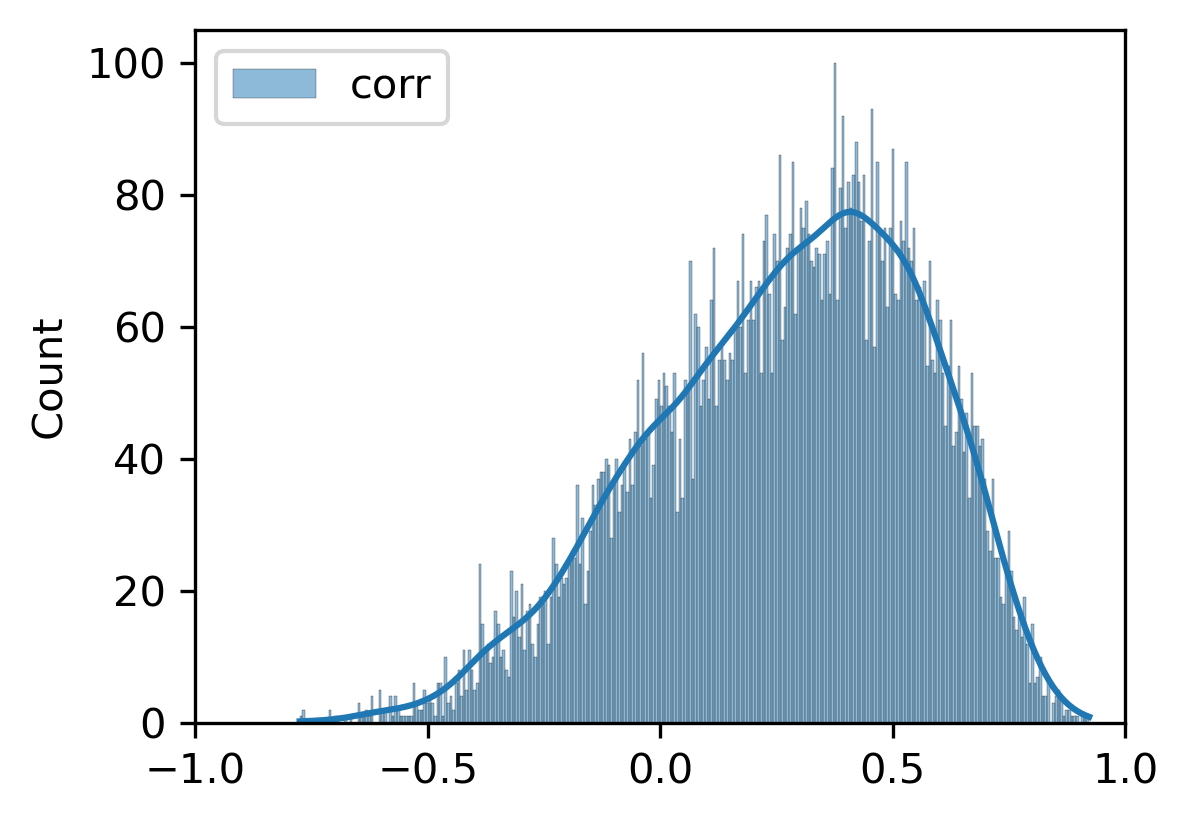

In [16]:
fig, ax = plt.subplots(figsize = (4,3), dpi = 300)
sns.histplot(corr_values, ax = ax,kde=True,bins=300, label = 'corr')
# sns.distplot(corr_df_diagonal_values_2, ax = ax,kde=True,bins=300, label = 'corr')
# sns.distplot(s_corr_df_diagonal_values,ax = ax, kde=True,bins=300, label = 'shuffle')

ax.set_xlim(-1,1)
# ax.axvline(x=0, color='red', linestyle='--', label='baseline')
# ax.set_xlabel(f'{mc_type} {condition} chr{chromosome}')
plt.legend()
# fig.savefig(f'./results/0413_filtered_exclude2_9_mc_rna_correlation.pdf', bbox_inches='tight')

In [17]:
#NOTE: arbitrary threshold for zscore filtering!!!
thres = -0.3
(corr_values<=thres).sum() # 392 genes

392

In [19]:
below_threshold = corr_values[corr_values<=thres]
thres_mc_df = final_meth_df.loc[below_threshold.index]
thres_mc_df

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0
AT1G02110,0.120550,0.174179,0.125939,0.091674,0.048103,0.069415,0.033571,0.161344,0.039669,0.118760,0.088348,0.134347,0.086127,0.063775,0.081252,0.186451,0.151441
AT1G05750,0.133545,0.173180,0.124340,0.113720,0.156139,0.130803,0.152387,0.177445,0.131047,0.100907,0.095604,0.146927,0.137662,0.127358,0.117289,0.156278,0.114326
AT1G06148,0.163536,0.193057,0.120980,0.106001,0.159300,0.112591,0.195946,0.177479,0.200497,0.082179,0.192409,0.086889,0.137165,0.190709,0.134038,0.147598,0.101182
AT1G07273,0.089240,0.125149,0.077116,0.076277,0.109442,0.092973,0.130226,0.160551,0.086436,0.049238,0.092779,0.050427,0.071870,0.167649,0.084493,0.083791,0.092043
AT1G07317,0.151510,0.245167,0.142067,0.101316,0.177568,0.142718,0.206670,0.250240,0.159120,0.081907,0.124176,0.123060,0.165978,0.309333,0.123504,0.162954,0.256579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G58980,0.157299,0.208997,0.156332,0.131090,0.176433,0.137991,0.184713,0.192844,0.130892,0.115403,0.120507,0.140545,0.171713,0.199375,0.153554,0.215285,0.149105
AT5G61865,0.070879,0.084570,0.071354,0.063320,0.060290,0.062641,0.086719,0.070570,0.048576,0.052496,0.054066,0.048510,0.071499,0.102382,0.051974,0.085327,0.035448
AT5G62680,0.110868,0.135843,0.096521,0.088189,0.128520,0.107919,0.111879,0.157300,0.090803,0.058682,0.103695,0.106471,0.092173,0.179731,0.114425,0.150946,0.105093
AT5G64240,0.141367,0.194820,0.111858,0.096412,0.142365,0.084954,0.156121,0.199256,0.119964,0.090616,0.097148,0.130117,0.124421,0.168281,0.116707,0.142695,0.177848


In [20]:
df_zscore = thres_mc_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
df_zscore

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0
AT1G02110,0.343042,1.482779,0.457580,-0.270632,-1.196632,-0.743690,-1.505463,1.210005,-1.375871,0.305004,-0.341328,0.636272,-0.388529,-0.863564,-0.492128,1.743597,0.999559
AT1G05750,-0.047089,1.650284,-0.441290,-0.896117,0.920490,-0.164527,0.759817,1.832948,-0.154067,-1.444814,-1.671920,0.526018,0.129213,-0.312049,-0.743240,0.926473,-0.870131
AT1G06148,0.403186,1.129592,-0.643945,-1.012528,0.298964,-0.850375,1.200676,0.746264,1.312663,-1.598703,1.113636,-1.482790,-0.245707,1.071802,-0.322650,0.011017,-1.131101
AT1G07273,-0.217831,0.866603,-0.583952,-0.609294,0.392268,-0.105088,1.019928,1.935713,-0.302517,-1.425861,-0.110943,-1.389940,-0.742397,2.150060,-0.361172,-0.382390,-0.133187
AT1G07317,-0.330839,1.181948,-0.483361,-1.141592,0.090056,-0.472848,0.560126,1.263886,-0.207916,-1.455089,-0.772339,-0.790376,-0.097146,2.218388,-0.783196,-0.145981,1.366280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G58980,-0.129117,1.539887,-0.160337,-0.975266,0.488597,-0.752475,0.755900,1.018419,-0.981651,-1.481714,-1.316936,-0.670017,0.336227,1.229257,-0.250024,1.742915,-0.393665
AT5G61865,0.289707,1.089331,0.317447,-0.151795,-0.328734,-0.191469,1.214852,0.271661,-1.012930,-0.783958,-0.692284,-1.016814,0.325894,2.129706,-0.814470,1.133546,-1.779689
AT5G62680,-0.109596,0.747391,-0.601936,-0.887821,0.496116,-0.210817,-0.074906,1.483687,-0.798143,-1.900331,-0.355736,-0.260493,-0.751125,2.253379,0.012442,1.265647,-0.307760
AT5G64240,0.180706,1.697186,-0.656449,-1.094663,0.209015,-1.419720,0.599281,1.823021,-0.426493,-1.259087,-1.073770,-0.138452,-0.300051,0.944269,-0.518881,0.218401,1.215689


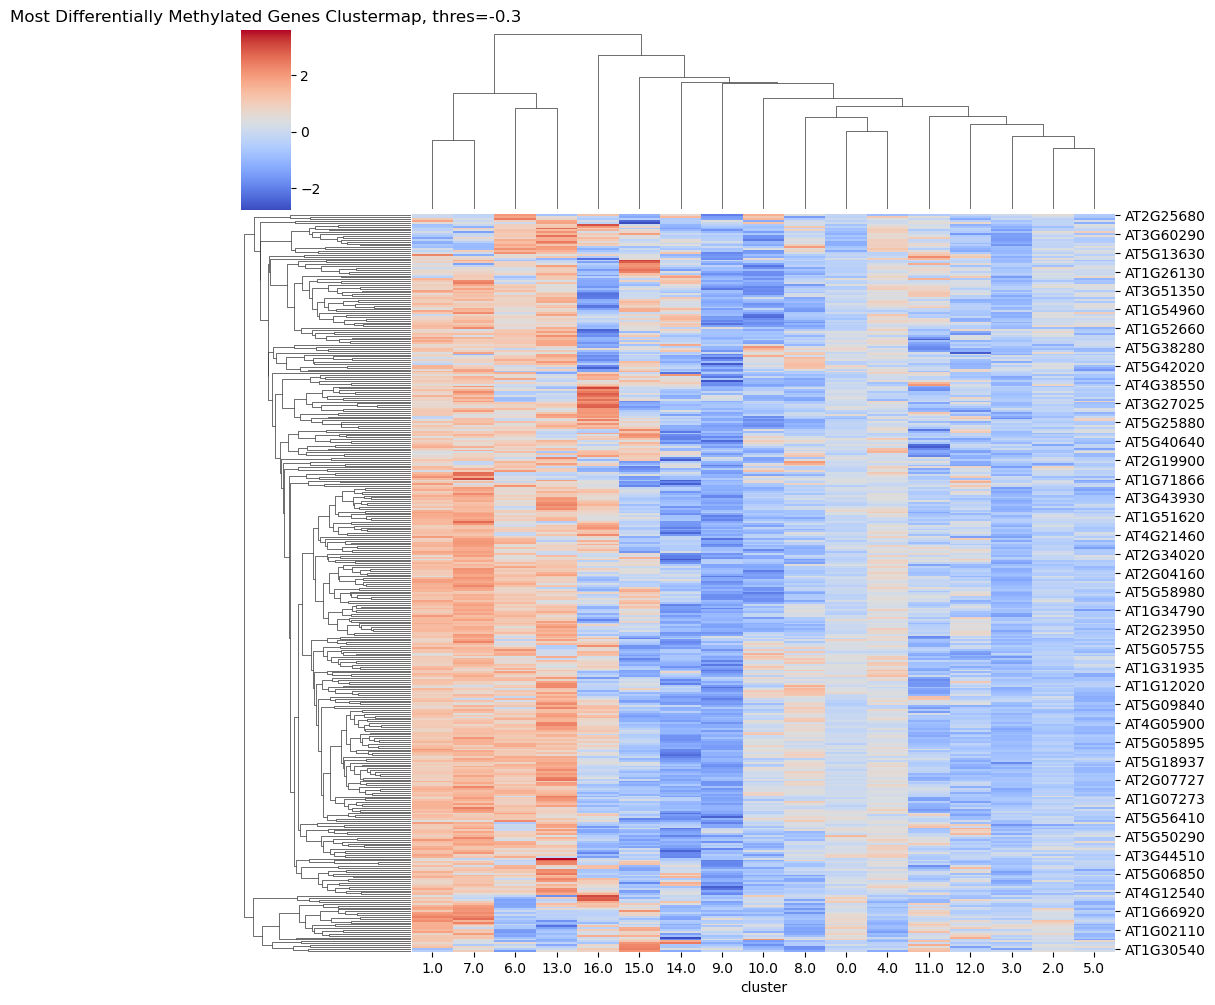

In [21]:
cluster = sns.clustermap(df_zscore, method='average', metric='euclidean', cmap='coolwarm', figsize=(10, 10))

plt.title(f'Most Differentially Methylated Genes Clustermap, thres={thres}')
# plt.savefig('./result/highMCClusterMap.pdf')
plt.show()

In [24]:
gene_order = cluster.dendrogram_row.reordered_ind
seurat_order = cluster.dendrogram_col.reordered_ind
thres_rna_df = final_rna_df.loc[below_threshold.index]
#thres_rna_df = filtered_rna_df.loc[below_threshold.index]
thres_rna_df_reordered = thres_rna_df.iloc[gene_order,seurat_order]

In [25]:
thres_rna_df_reordered

cluster,1,7,6,13,16,15,14,9,10,8,0,4,11,12,3,2,5
AT2G25680,0.020233,0.009050,0.018673,0.010576,0.000000,0.000000,0.000000,0.560087,0.020609,0.008837,0.024252,0.018236,0.058209,0.000000,0.024302,0.025303,0.044757
AT5G12920,0.039696,0.046041,0.007551,0.072246,0.000000,0.089614,0.030741,0.039988,0.007331,0.005026,0.028287,0.049953,0.000000,0.096597,0.023340,0.038927,0.082372
AT5G46290,0.240545,0.496800,0.280111,0.567053,0.582755,0.420291,0.407317,0.434577,0.231144,0.265742,0.311419,0.398949,0.335368,0.384631,0.417725,0.247426,0.625692
AT3G15140,0.041374,0.143954,0.049115,0.077935,0.000000,0.139782,0.000000,0.011564,0.080420,0.053933,0.026526,0.046184,0.010918,0.144917,0.034803,0.033345,0.043099
AT5G39740,0.820009,1.297972,0.820377,1.585206,2.047683,2.036233,0.624275,0.962143,0.782769,0.722541,0.729889,0.550694,0.609515,1.237840,0.945173,0.929673,1.963162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT4G32940,1.930774,1.468818,1.196871,1.097288,2.162526,0.105842,0.368607,1.806838,1.488754,0.773938,0.677105,0.952087,1.277595,0.488584,0.347295,0.671886,0.316293
AT1G29435,0.035189,0.097405,0.034301,0.152173,0.025004,0.000000,0.000000,0.000000,0.007331,0.065503,0.025948,0.162800,0.000000,0.000000,0.000000,0.009622,0.073577
AT3G16030,0.232087,0.094890,0.242192,0.384216,0.149653,0.154282,0.000000,0.150755,0.305805,0.875255,0.093370,0.234688,0.052030,0.000000,0.029160,0.033973,0.023521
AT1G30540,0.264205,0.260808,0.199416,0.222316,0.106022,0.000000,0.099856,0.126518,0.096833,0.317647,0.135191,0.143142,0.118248,0.096668,0.092424,0.162092,0.114609


In [26]:
rna_zscore = thres_rna_df_reordered.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
# rna_zscore

<Axes: xlabel='cluster'>

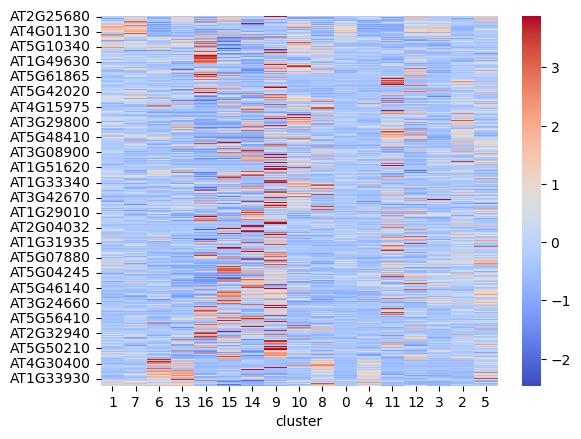

In [27]:
sns.heatmap(rna_zscore,cmap = 'coolwarm')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

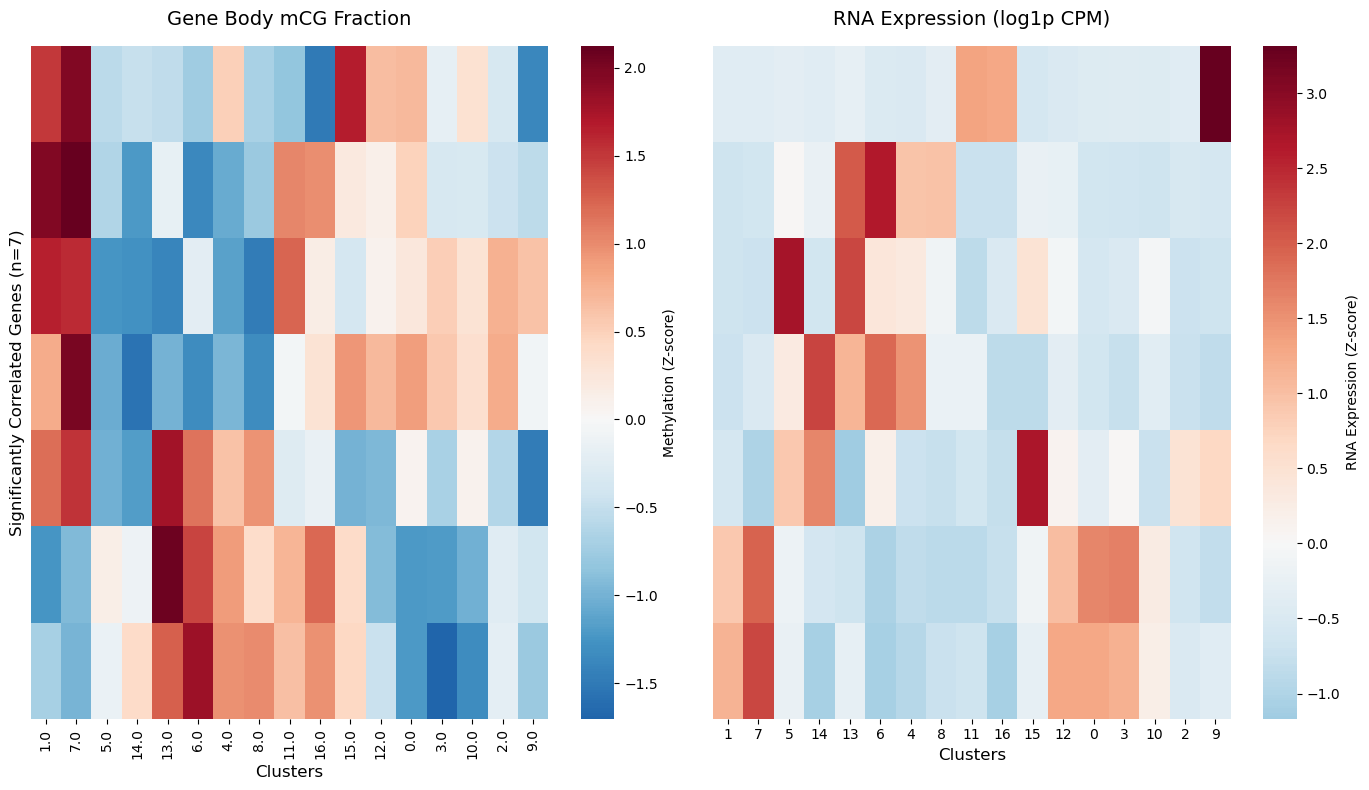

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from statsmodels.stats.multitest import multipletests

# ---------------------------------------------------------
# 1. Calculate Per-Gene Spearman Correlation
# ---------------------------------------------------------
correlations = []
p_values = []
genes = final_meth_df.index

for gene in genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    
    # Check for zero variance to avoid ConstantInputWarning
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        correlations.append(np.nan)
        p_values.append(np.nan)
        continue
        
    rho, p = spearmanr(rna_vals, meth_vals)
    correlations.append(rho)
    p_values.append(p)

stats_df = pd.DataFrame({
    'gene': genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Drop NaNs that occur if a gene has zero variance across clusters
stats_df = stats_df.dropna()

# Apply FDR correction (Benjamini-Hochberg)
stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

# ---------------------------------------------------------
# 2. Filter for Significant Negative Correlation
# ---------------------------------------------------------
# Adjust these thresholds based on how many genes you want to visualize
RHO_THRESH = -0.5
FDR_THRESH = 0.05

sig_genes = stats_df[(stats_df['rho'] <= RHO_THRESH) & (stats_df['fdr'] <= FDR_THRESH)].index

# Subset the original dataframes
vis_rna = final_rna_df.loc[sig_genes]
vis_meth = final_meth_df.loc[sig_genes].copy()

# Apply baseline contrast rule to zero-methylation instances
vis_meth[vis_meth == 0] = -0.2

# ---------------------------------------------------------
# 3. Z-Score Normalization
# ---------------------------------------------------------
vis_rna_z = vis_rna.apply(zscore, axis=1)
vis_meth_z = vis_meth.apply(zscore, axis=1)

# ---------------------------------------------------------
# 4. Publication-Ready Visualization
# ---------------------------------------------------------
# Set global aesthetic parameters for Nature standard
plt.rcParams['pdf.fonttype'] = 42
# plt.rcParams['font.sans-serif'] = "Arial"  <- Comment this out
plt.rcParams['font.family'] = "sans-serif"   # Will use the system default sans-serif

# We will use seaborn's clustermap, but we only want to cluster the rows (genes) 
# and columns (clusters) once so the order matches perfectly between both plots.

# Perform hierarchical clustering on the Methylation data to dictate the order
cluster_grid = sns.clustermap(vis_meth_z, cmap="RdBu_r", figsize=(10, 8))
plt.close() # Close this temporary figure

# Extract the sorted order
row_order = cluster_grid.dendrogram_row.reordered_ind
col_order = cluster_grid.dendrogram_col.reordered_ind

# Sort both matrices by the same hierarchical clustering
vis_meth_sorted = vis_meth_z.iloc[row_order, col_order]
vis_rna_sorted = vis_rna_z.iloc[row_order, col_order]

# Plot side-by-side heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={'width_ratios': [1, 1]})

# Methylation Heatmap
sns.heatmap(vis_meth_sorted, cmap="RdBu_r", center=0, ax=ax1, 
            cbar_kws={'label': 'Methylation (Z-score)'}, yticklabels=False)
ax1.set_title("Gene Body mCG Fraction", fontsize=14, pad=15)
ax1.set_xlabel("Clusters", fontsize=12)
ax1.set_ylabel(f"Significantly Correlated Genes (n={len(sig_genes)})", fontsize=12)

# RNA Heatmap
sns.heatmap(vis_rna_sorted, cmap="RdBu_r", center=0, ax=ax2, 
            cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=14, pad=15)
ax2.set_xlabel("Clusters", fontsize=12)
ax2.set_ylabel("")

plt.tight_layout()

# Save as vector graphic for publication assembly
plt.savefig("rna_meth_negative_correlation.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Initialize lists to store our valid results
correlations = []
p_values = []
valid_genes = []

# Iterate over each gene in the aligned dataframes
for gene in final_rna_df.index:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    
    # Check for zero variance to avoid mathematical errors
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue  # Skip this gene and move to the next one
        
    # Calculate Spearman rank correlation
    rho, p = spearmanr(rna_vals, meth_vals)
    
    # Store the results
    valid_genes.append(gene)
    correlations.append(rho)
    p_values.append(p)

# Compile the results into a clean DataFrame
corr_df = pd.DataFrame({
    'gene': valid_genes,
    'spearman_rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Sort by spearman_rho in ascending order
# This pushes the strongest negative correlations (e.g., -0.8, -0.9) to the very top
top_inverse_genes = corr_df.sort_values(by='spearman_rho', ascending=True)



Top 10 genes with the strongest negative correlation (RNA vs. Methylation):
           spearman_rho   p_value
gene                             
AT2G07638     -0.791667  0.000153
AT2G10940     -0.772059  0.000282
AT4G01130     -0.761673  0.000381
AT1G17920     -0.730392  0.000870
AT3G43270     -0.723039  0.001039
AT4G30400     -0.723039  0.001039
AT1G62030     -0.709994  0.001407
AT2G07698     -0.681373  0.002597
AT4G18970     -0.674020  0.003008
AT2G13820     -0.669556  0.003282


In [32]:
# Display the top 10 strongest inverse relationships
print("Top 10 genes with the strongest negative correlation (RNA vs. Methylation):")
print(top_inverse_genes.head(20))

Top 10 genes with the strongest negative correlation (RNA vs. Methylation):
           spearman_rho   p_value
gene                             
AT2G07638     -0.791667  0.000153
AT2G10940     -0.772059  0.000282
AT4G01130     -0.761673  0.000381
AT1G17920     -0.730392  0.000870
AT3G43270     -0.723039  0.001039
AT4G30400     -0.723039  0.001039
AT1G62030     -0.709994  0.001407
AT2G07698     -0.681373  0.002597
AT4G18970     -0.674020  0.003008
AT2G13820     -0.669556  0.003282
AT1G29910     -0.666667  0.003470
AT2G07681     -0.657266  0.004144
AT5G48690     -0.652656  0.004511
AT2G28170     -0.649908  0.004742
AT5G09840     -0.645211  0.005159
AT2G01010     -0.644608  0.005214
AT3G23450     -0.642157  0.005446
AT2G05665     -0.623660  0.007468
AT5G22860     -0.619252  0.008030
AT2G07655     -0.614347  0.008693
